In [ ]:
# NOTE: This is an old lab notebook from Debo, very helpful back in the day
import numpy as np
from scipy.special import eval_genlaguerre as laguerre
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties.umath import *

# Read H5

In [2]:
THRESHOLD = 1
Y_MAX = 1
HBAR = 1.0546e-34
M = 170.9*1.66e-27
WAVELENGTH = 435.5e-9 
N_MAX = 3500

def extract_df(rid):
    file = h5py.File(f"./data/000{rid}-Scan435Seq.h5")
    data = file['datasets']['histogram_context']['histogram']['raw']
    num_points = len(data)
    num_shots = len(data["1"])
    num_pmt = len(data["1"][0])
    pmt_data = np.zeros((num_pmt, num_points))
    pmt_err = np.zeros((num_pmt, num_points))

    for i in range (0, num_points):
        # point data is (num pmt * num shots)
        point_data = np.array(data['{}'.format(i)]).transpose()
        for pmt in range(0, len(point_data)):
            pmt_data[pmt][i] = np.mean(point_data[pmt] > THRESHOLD)

    for pmt in range(num_pmt):
        for i in range(num_points):
            perr = np.sqrt(pmt_data[pmt][i] * (Y_MAX-pmt_data[pmt][i])/num_shots)
            pmt_err[pmt][i] = 0.001 if perr == 0 else perr
            

    x = np.array(file['datasets']['scan']['duration'])
    df = pd.DataFrame({}, index=x[:num_points])

    for pmt in range(num_pmt):
        df['pmt_{}'.format(pmt)] = pmt_data[pmt]
        df['err_{}'.format(pmt)] = pmt_err[pmt]
    return df

# df_axial = extract_df(120177)
# df_axial.sort_index(inplace=True)
# df_axial.plot()

# Define thermal dynamics

In [3]:
def thermal(nbar, n):
    return 1./ (nbar + 1.0) * (nbar / (nbar + 1.0))**n

def eta(trap_freq_rad_per_s, beam_angle_rad):
    return 2*np.pi/WAVELENGTH * np.sqrt(HBAR/(2*M*trap_freq_rad_per_s)) *np.cos(beam_angle_rad)

def rabi_coupling_func(sideband_order, eta):
    if sideband_order == 0:
        # assumes carrier is mostly heating from axial
        coupling_func = lambda n: np.exp(-1./2*eta**2) * laguerre(n, 0, eta**2)
    elif sideband_order == 1:
        coupling_func = lambda n: np.exp(-1./2*eta**2) * eta**(1)*(1./(n+1.))**0.5 * laguerre(n, 1, eta**2)
    elif sideband_order == 2:
        coupling_func = lambda n: np.exp(-1./2*eta**2) * eta**(2)*(1./((n+1.)*(n+2)))**0.5 * laguerre(n, 2, eta**2)
    elif sideband_order == 3:
        coupling_func = lambda n: np.exp(-1./2*eta**2) * eta**(3)*(1./((n+1)*(n+2)*(n+3)))**0.5 * laguerre(n, 3 , eta**2) 
    elif sideband_order == 4:
        coupling_func = lambda n: np.exp(-1./2*eta**2) * eta**(4)*(1./((n+1)*(n+2)*(n+3)*(n+4)))**0.5 * laguerre(n, 4 , eta**2)
    elif sideband_order == 5:
        coupling_func = lambda n: np.exp(-1./2*eta**2) * eta**(5)*(1./((n+1)*(n+2)*(n+3)*(n+4)*(n+5)))**0.5 * laguerre(n, 5 , eta**2)     
    elif sideband_order == -1:
        coupling_func = lambda n: 0 if n == 0 else np.exp(-1./2*eta**2) * eta**(1)*(1./(n))**0.5 * laguerre(n - 1, 1, eta**2)
    elif sideband_order == -2:
        coupling_func = lambda n: 0 if n <= 1 else np.exp(-1./2*eta**2) * eta**(2)*(1./((n)*(n-1.)))**0.5 * laguerre(n - 2, 2, eta**2)
    elif sideband_order == -3:
        coupling_func = lambda n: 0 if n <= 2 else np.exp(-1./2*eta**2) * eta**(3)*(1./((n)*(n-1.)*(n-2)))**0.5 * laguerre(n -3, 3, eta**2)
    elif sideband_order == -4:
        coupling_func = lambda n: 0 if n <= 3 else np.exp(-1./2*eta**2) * eta**(4)*(1./((n)*(n-1.)*(n-2)*(n-3)))**0.5 * laguerre(n -4, 4, eta**2)
    elif sideband_order == -5:
        coupling_func = lambda n: 0 if n <= 4 else np.exp(-1./2*eta**2) * eta**(5)*(1./((n)*(n-1.)*(n-2)*(n-3)*(n-4)))**0.5 * laguerre(n -5, 5, eta**2)
    else:
        raise ValueError(f"sideband order {sideband_order} not supported")
    return coupling_func

class RabiFlopWithThermal:
    def __init__(self, trap_freq_hz, beam_angle_degree, nbar, sideband_order):
        self.eta = eta(trap_freq_hz * 2 * np.pi, np.deg2rad(beam_angle_degree))
        # calculate population distribution in number states
        self.pns = np.fromfunction(lambda n: thermal(nbar, n), (N_MAX,))
        # calculate coupling using laguerre polynomials
        rabi_coupling = rabi_coupling_func(sideband_order, self.eta)
        self.rabi_couplings = np.array([rabi_coupling(n) for n in range(N_MAX)])

    def probability_thermal(self, t, pi_time, detune_rad): 
        times = np.ones_like(t)
        Omegas = np.pi / pi_time * self.rabi_couplings
        # avoid division by zero
        Omegas[Omegas == 0] = 1
        generalized_rabi = np.sqrt(Omegas**2 + detune_rad**2)
        # scalings = Omegas ** 2 /(Omegas**2 + detune_rad**2)
        result = np.outer(self.pns * (Omegas/generalized_rabi)**2, times) *  (np.sin(np.outer(generalized_rabi/ 2, t))**2)
        result = np.sum(result, axis = 0)
        return result

Text(0.5, 1.0, 'Rabi Flop with nbar = 20')

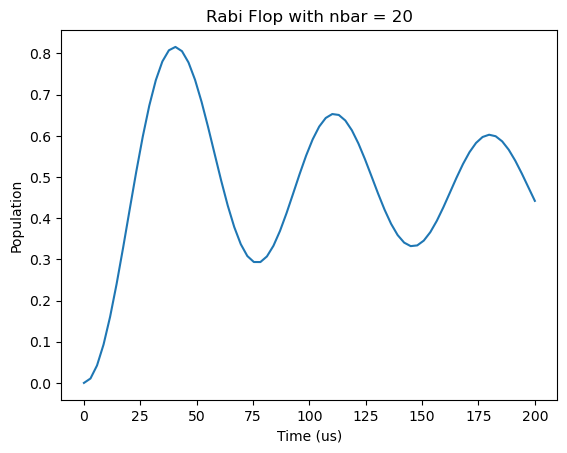

In [4]:
nbar = 20
times = np.linspace(0, 200e-6, 70)
rabi_flop = RabiFlopWithThermal(trap_freq_hz=111e3, beam_angle_degree=45, nbar=nbar, sideband_order=-1)
probabilities = rabi_flop.probability_thermal(times, pi_time=20e-6, detune_rad=0)
plt.plot(times*1e6, probabilities)
plt.xlabel("Time (us)")
plt.ylabel("Population")
plt.title(f"Rabi Flop with nbar = {nbar}")

# Fit Carrier

[ 6.92498102e-06  9.12177381e-01  4.29551607e+01  6.23059546e-03
 -1.94388746e-07]


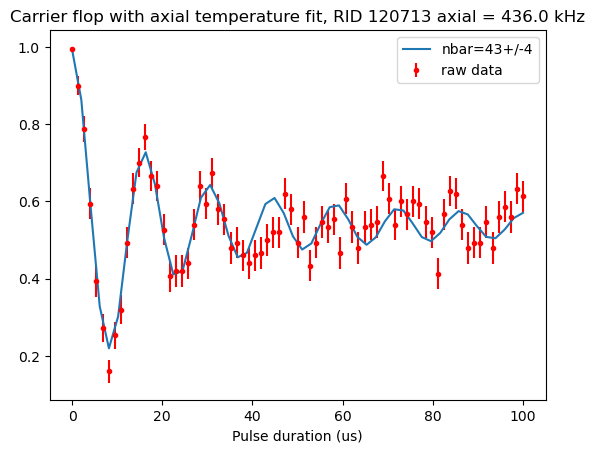

In [24]:
AXIAL_FREQ = 436e03
RID = 120713
df = extract_df(RID)
df.sort_index(inplace=True)

def rabi_flop_fit(times, pi_time, scaling, nbar, spam, delay, sideband_order):
    rabi_flop = RabiFlopWithThermal(trap_freq_hz=AXIAL_FREQ, beam_angle_degree=45, nbar=nbar, sideband_order=sideband_order)
    probabilities = rabi_flop.probability_thermal(times - delay, pi_time=pi_time, detune_rad=0)
    return 1 - scaling * probabilities - spam

carrier_flop_fit = lambda times, pi_time, scaling, nbar, spam, delay: rabi_flop_fit(times, pi_time, scaling, nbar, spam, delay, 0)

popt, pcov = curve_fit(
    carrier_flop_fit,
    df.index.values, 
    df['pmt_0'],
    sigma=df['err_0'], 
    p0 = [9e-6, 1.0, 75, 0, 0],
    bounds=([1e-6, 0.3, 0, 0, -10e-6], [100e-6, 1, 500, 0.1, +10e-6]),
    max_nfev=10000)
perr = np.sqrt(np.diag(pcov))
print(popt)

plt.errorbar(df.index.values * 1e6, df['pmt_0'], df['err_0'], marker='.', color='r',linestyle='', label='raw data')
x_range = np.linspace(0, max(df.index.values))
plt.plot(x_range * 1e6, carrier_flop_fit(x_range, *popt), label=f"nbar={str(ufloat(popt[2], perr[2]))}")
plt.title(f"Carrier flop with axial temperature fit, RID {RID} axial = {round(AXIAL_FREQ * 1e-3, 2)} kHz")
plt.xlabel(f"Pulse duration (us)")
plt.legend()

# Fit Axial 

[ 9.24988564e-06  9.03284755e-01  1.37789627e+02  1.46552148e-59
 -2.08238180e-06]


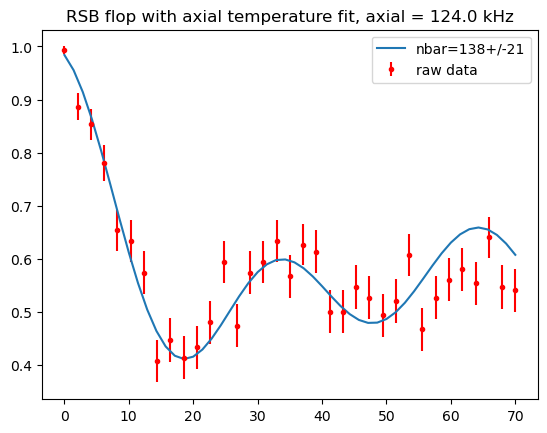

In [ ]:
AXIAL_FREQ = 124e03 #np.sqrt(0.07) * 1e6
RID = 120629
df = extract_df(RID)
df.sort_index(inplace=True)

rsb_flop_fit = lambda times, pi_time, scaling, nbar, spam, delay: rabi_flop_fit(times, pi_time, scaling, nbar, spam, delay, -1)

popt, pcov = curve_fit(
    rsb_flop_fit, 
    df.index.values, 
    df['pmt_0'],
    sigma=df['err_0'], 
    p0 = [20e-6, 1, 100, 0, 0],
    bounds=([1e-6, 0.3, 0, 0, -10e-6], [100e-6, 1, 500, 0.1, +10e-6]))
perr = np.sqrt(np.diag(pcov))
print(popt)

plt.errorbar(df.index.values * 1e6, df['pmt_0'], df['err_0'], marker='.', color='r',linestyle='', label='raw data')
x_range = np.linspace(0, max(df.index.values))
plt.plot(x_range * 1e6, rsb_flop_fit(x_range, *popt), label=f"nbar={str(ufloat(popt[2], perr[2]))}")
plt.title(f"flop with axial temperature fit, axial = {round(AXIAL_FREQ * 1e-3, 2)} kHz")
plt.legend()

# Fit carrier & axial together

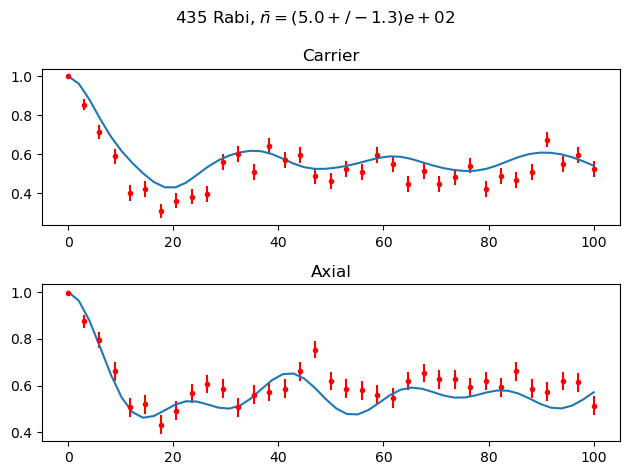

In [91]:
N_GUESS = 100
PI_TIME_GUESS = 5e-6

df_carrier = extract_df(120405)
df_axial = extract_df(120410)

df_carrier.sort_index(inplace=True)
df_axial.sort_index(inplace=True)
split_ind = len(df_carrier)

def fit_together(times, pi_time, scaling, nbar, spam, delay):
    # split the times int
    carrier_results = rabi_flop_fit(times[:split_ind], pi_time, scaling, nbar, spam, delay, 0)
    axial_results = rabi_flop_fit(times[split_ind:], pi_time, scaling, nbar, spam, delay, 1)
    results = np.concatenate((carrier_results, axial_results))
    return results
popt, pcov = curve_fit(
    fit_together, 
    np.concatenate((df_carrier.index.values, df_axial.index.values)), 
    np.concatenate((df_carrier['pmt_0'], df_axial['pmt_0'])),
    sigma=np.concatenate((df_carrier['err_0'], df_axial['err_0'])), 
    p0 = [PI_TIME_GUESS, 1, N_GUESS, 0, 0],
    bounds=([1e-6, 0.3, 0, 0, -10e-6], [100e-6, 1, 500, 0.1, +10e-6]))
perr = np.sqrt(np.diag(pcov))

fig, axs = plt.subplots(2, dpi=100)
fig.suptitle(rf'435 Rabi, $\bar{{n}}={str(ufloat(popt[2], perr[2]))}$')
axs[0].errorbar(df_carrier.index.values * 1e6, df_carrier['pmt_0'], df_carrier['err_0'], marker='.', color='r',linestyle='')
x_range1 = np.linspace(0, max(df_carrier.index.values))
axs[0].plot(x_range1 * 1e6, rabi_flop_fit(x_range1, *popt, 0), color='C0')
axs[0].set_title('Carrier')

axs[1].errorbar(df_axial.index.values * 1e6, df_axial['pmt_0'], df_axial['err_0'], marker='.', color='r',linestyle='')
x_range2 = np.linspace(0, max(df_axial.index.values))
axs[1].plot(x_range2 * 1e6, rabi_flop_fit(x_range2, *popt, -1), color='C0')
axs[1].set_title('Axial')
fig.tight_layout()

# Fit multiple

In [41]:
N_GUESS = 200
PI_TIME_GUESS = 20e-6
AXIAL_FREQ = 124e03

def rabi_flop_fit(times, pi_time, scaling, nbar, spam, delay, sideband_order):
    rabi_flop = RabiFlopWithThermal(trap_freq_hz=AXIAL_FREQ, beam_angle_degree=45, nbar=nbar, sideband_order=sideband_order)
    probabilities = rabi_flop.probability_thermal(times - delay, pi_time=pi_time, detune_rad=0)
    return 1 - scaling * probabilities - spam

# RID to sideband order
data = {
    120663: 0, 
    120664: 1,
    120665: 2,
    120666: 3,
    120667: 4,
    # 120647: 5,
}
dfs = []
indices = []
i = 0 
rids = sorted(data.keys())
for rid in rids:
    df = extract_df(rid)
    df.sort_index(inplace=True)
    dfs.append(df)
    indices.append((i, i+len(df)))
    i += len(df)

def fit_together(times, pi_time, scaling, nbar, spam, delay):
    # split the times int
    results = np.array([])
    for i, rid in enumerate(rids):
        start, end = indices[i]
        new_results = rabi_flop_fit(times[start:end], pi_time, scaling, nbar, spam, delay, data[rid])
        results = np.concatenate((results, new_results))
    return results

popt, pcov = curve_fit(
    fit_together, 
    np.concatenate([df.index.values for df in dfs]), 
    np.concatenate([df['pmt_0'] for df in dfs]),
    sigma=np.concatenate([df['err_0'] for df in dfs]), 
    p0 = [PI_TIME_GUESS, 1, N_GUESS, 0, 0],
    bounds=([1e-6, 0.3, 0, 0, -10e-6], [60e-6, 1, 500, 0.1, +10e-6]),
    max_nfev=1000)
    # ftol=1e-10)
perr = np.sqrt(np.diag(pcov))

fig, axs = plt.subplots(len(dfs), dpi=100, figsize=(5, 10))
fig.suptitle(rf'435 Rabi, $\bar{{n}}={str(ufloat(popt[2], perr[2]))}$')
for i in range(len(dfs)):
    axs[i].errorbar(dfs[i].index.values * 1e6, dfs[i]['pmt_0'], dfs[i]['err_0'], marker='.', color='r',linestyle='')
    x_range = np.linspace(0, max(dfs[i].index.values))
    axs[i].plot(x_range * 1e6, rabi_flop_fit(x_range, *popt, data[rids[i]]), color='C0')
    axs[i].set_title(f'RID {rids[i]}, sideband order {data[rids[i]]}')

fig.tight_layout()

KeyboardInterrupt: 